In [1]:
#N1: imports + load CIFAR-100 (pickled batches: meta, train, test)



import os
N_THREADS = 16                                   # 64 cores / 4 notebooks
os.environ["OMP_NUM_THREADS"] = str(N_THREADS)   # must be set BEFORE importing torch/numpy
os.environ["MKL_NUM_THREADS"] = str(N_THREADS)

import pickle
import numpy as np
import torch
torch.set_num_threads(N_THREADS)                 # PyTorch uses only these cores
print("threads:", torch.get_num_threads())

#os.sched_setaffinity(0, range(0, 16))    # file 1
os.sched_setaffinity(0, range(16, 32)) # file 2
# os.sched_setaffinity(0, range(32, 48)) # file 3
# os.sched_setaffinity(0, range(48, 64)) # file 4



import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import time
import matplotlib.pyplot as plt

# CIFAR-100 gives you 3 files directly: meta, train, test — point BASE at the folder holding them
BASE = '/home/worker/Downloads/talha/week6/cifar notebooks/cifar-100/'

def unpickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f, encoding='latin1')

meta  = unpickle(f'{BASE}/meta')
train = unpickle(f'{BASE}/train')
test  = unpickle(f'{BASE}/test')

fine_names = meta['fine_label_names']          # 100 names, index = fine label

x_train_all = train['data']                     # [50000, 3072] uint8, R-block+G-block+B-block per row (converted to 784 in N2)
y_train_all = np.array(train['fine_labels'])     # [50000] values 0-99

x_test_all  = test['data']                       # [10000, 3072]
y_test_all  = np.array(test['fine_labels'])       # [10000]

print(f"train: {x_train_all.shape}   test: {x_test_all.shape}")
print(f"fine labels: {y_train_all.min()} to {y_train_all.max()}  (100 classes total)")


threads: 16
train: (50000, 3072)   test: (10000, 3072)
fine labels: 0 to 99  (100 classes total)


after conversion  train: (50000, 784)   test: (10000, 784)


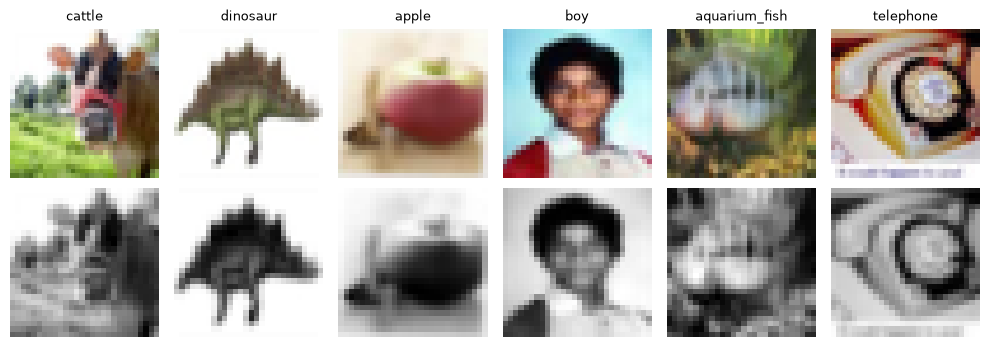

In [2]:
#N2: convert CIFAR-100 to 28x28 grayscale (same input format as EMNIST: 784 values per image)
# CIFAR images are already upright, so no rotation fix is needed (unlike EMNIST)

from PIL import Image

def to_gray28(rows):
    """rows: [N, 3072] uint8 in CIFAR order (1024 red, 1024 green, 1024 blue)
       returns [N, 784] uint8 = 28x28 grayscale, flattened"""
    out = np.empty((len(rows), 784), dtype=np.uint8)
    for i, r in enumerate(rows):
        rgb = r.reshape(3, 32, 32).transpose(1, 2, 0)              # 32x32x3
        img = Image.fromarray(rgb, 'RGB').convert('L')              # grayscale: 0.299R + 0.587G + 0.114B
        img = img.resize((28, 28), Image.BILINEAR)                  # 32x32 -> 28x28 (whole image, no cropping)
        out[i] = np.asarray(img, dtype=np.uint8).reshape(-1)
    return out

x_train_color = x_train_all                     # keep the originals only for the visual check below
x_train_all   = to_gray28(x_train_all)          # [50000, 784]
x_test_all    = to_gray28(x_test_all)           # [10000, 784]
print(f"after conversion  train: {x_train_all.shape}   test: {x_test_all.shape}")

# visual check: top = original 32x32 color, bottom = 28x28 grayscale
fig, axes = plt.subplots(2, 6, figsize=(10, 3.6))
for k in range(6):
    axes[0, k].imshow(x_train_color[k].reshape(3, 32, 32).transpose(1, 2, 0))
    axes[0, k].set_title(fine_names[y_train_all[k]], fontsize=9)
    axes[1, k].imshow(x_train_all[k].reshape(28, 28), cmap='gray')
    axes[0, k].axis('off'); axes[1, k].axis('off')
plt.tight_layout(); plt.show()
del x_train_color


In [3]:
#N3: defining 20 problems — the 20 CIFAR-100 superclasses, 5 fine classes each

SCRIPT_NAMES = ["P1_aquatic", "P2_fish", "P3_flowers", "P4_containers", "P5_produce",
                "P6_devices", "P7_furniture", "P8_insects", "P9_carnivores", "P10_outdoor_things",
                "P11_outdoor_scenes", "P12_omni_herbivores", "P13_medium_mammals", "P14_invertebrates", "P15_people",
                "P16_reptiles", "P17_small_mammals", "P18_trees", "P19_vehicles_1", "P20_vehicles_2"]

GROUP_CLASS_NAMES = [
    ["beaver", "dolphin", "otter", "seal", "whale"],                     # P1
    ["aquarium_fish", "flatfish", "ray", "shark", "trout"],              # P2
    ["orchid", "poppy", "rose", "sunflower", "tulip"],                   # P3
    ["bottle", "bowl", "can", "cup", "plate"],                           # P4
    ["apple", "mushroom", "orange", "pear", "sweet_pepper"],             # P5
    ["clock", "keyboard", "lamp", "telephone", "television"],            # P6
    ["bed", "chair", "couch", "table", "wardrobe"],                      # P7
    ["bee", "beetle", "butterfly", "caterpillar", "cockroach"],          # P8
    ["bear", "leopard", "lion", "tiger", "wolf"],                        # P9
    ["bridge", "castle", "house", "road", "skyscraper"],                 # P10
    ["cloud", "forest", "mountain", "plain", "sea"],                     # P11
    ["camel", "cattle", "chimpanzee", "elephant", "kangaroo"],           # P12
    ["fox", "porcupine", "possum", "raccoon", "skunk"],                  # P13
    ["crab", "lobster", "snail", "spider", "worm"],                      # P14
    ["baby", "boy", "girl", "man", "woman"],                             # P15
    ["crocodile", "dinosaur", "lizard", "snake", "turtle"],              # P16
    ["hamster", "mouse", "rabbit", "shrew", "squirrel"],                 # P17
    ["maple_tree", "oak_tree", "palm_tree", "pine_tree", "willow_tree"], # P18
    ["bicycle", "bus", "motorcycle", "pickup_truck", "train"],           # P19
    ["lawn_mower", "rocket", "streetcar", "tank", "tractor"],            # P20
]

name_to_fine = {n: i for i, n in enumerate(fine_names)}
GROUP_LABELS = [[name_to_fine[n] for n in grp] for grp in GROUP_CLASS_NAMES]

for names, labels in zip(GROUP_CLASS_NAMES, GROUP_LABELS):
    print(list(zip(names, labels)))

print("\n20 problems, 5 classes each, all 100 CIFAR-100 fine classes used")


[('beaver', 4), ('dolphin', 30), ('otter', 55), ('seal', 72), ('whale', 95)]
[('aquarium_fish', 1), ('flatfish', 32), ('ray', 67), ('shark', 73), ('trout', 91)]
[('orchid', 54), ('poppy', 62), ('rose', 70), ('sunflower', 82), ('tulip', 92)]
[('bottle', 9), ('bowl', 10), ('can', 16), ('cup', 28), ('plate', 61)]
[('apple', 0), ('mushroom', 51), ('orange', 53), ('pear', 57), ('sweet_pepper', 83)]
[('clock', 22), ('keyboard', 39), ('lamp', 40), ('telephone', 86), ('television', 87)]
[('bed', 5), ('chair', 20), ('couch', 25), ('table', 84), ('wardrobe', 94)]
[('bee', 6), ('beetle', 7), ('butterfly', 14), ('caterpillar', 18), ('cockroach', 24)]
[('bear', 3), ('leopard', 42), ('lion', 43), ('tiger', 88), ('wolf', 97)]
[('bridge', 12), ('castle', 17), ('house', 37), ('road', 68), ('skyscraper', 76)]
[('cloud', 23), ('forest', 33), ('mountain', 49), ('plain', 60), ('sea', 71)]
[('camel', 15), ('cattle', 19), ('chimpanzee', 21), ('elephant', 31), ('kangaroo', 38)]
[('fox', 34), ('porcupine', 63)

In [4]:
#N4: building 20 datasets

train_datasets = []
test_datasets  = []

for m in range(20):
    labels = GROUP_LABELS[m]

    mask     = np.isin(y_train_all, labels)
    x_tr     = x_train_all[mask].astype(np.float32).copy()
    y_tr_raw = y_train_all[mask].copy()
    y_tr     = np.zeros(len(y_tr_raw), dtype=np.int64)
    for new_label, old_label in enumerate(labels):
        y_tr[y_tr_raw == old_label] = new_label

    mask     = np.isin(y_test_all, labels)
    x_te     = x_test_all[mask].astype(np.float32).copy()
    y_te_raw = y_test_all[mask].copy()
    y_te     = np.zeros(len(y_te_raw), dtype=np.int64)
    for new_label, old_label in enumerate(labels):
        y_te[y_te_raw == old_label] = new_label

    x_tr = torch.tensor(x_tr, dtype=torch.float32)
    x_te = torch.tensor(x_te, dtype=torch.float32)
    y_tr = torch.tensor(y_tr, dtype=torch.long)
    y_te = torch.tensor(y_te, dtype=torch.long)

    mean = x_tr.mean()
    std  = x_tr.std()
    x_tr = (x_tr - mean) / std
    x_te = (x_te - mean) / std

    train_datasets.append(TensorDataset(x_tr, y_tr))
    test_datasets.append(TensorDataset(x_te, y_te))

    print(f"{SCRIPT_NAMES[m]}: train {len(x_tr):5d}  test {len(x_te):4d}  "
          f"mean {x_tr.mean():.2f}  std {x_tr.std():.2f}")


P1_aquatic: train  2500  test  500  mean -0.00  std 1.00
P2_fish: train  2500  test  500  mean -0.00  std 1.00
P3_flowers: train  2500  test  500  mean 0.00  std 1.00
P4_containers: train  2500  test  500  mean -0.00  std 1.00
P5_produce: train  2500  test  500  mean 0.00  std 1.00
P6_devices: train  2500  test  500  mean -0.00  std 1.00
P7_furniture: train  2500  test  500  mean 0.00  std 1.00
P8_insects: train  2500  test  500  mean 0.00  std 1.00
P9_carnivores: train  2500  test  500  mean -0.00  std 1.00
P10_outdoor_things: train  2500  test  500  mean 0.00  std 1.00
P11_outdoor_scenes: train  2500  test  500  mean -0.00  std 1.00
P12_omni_herbivores: train  2500  test  500  mean -0.00  std 1.00
P13_medium_mammals: train  2500  test  500  mean -0.00  std 1.00
P14_invertebrates: train  2500  test  500  mean 0.00  std 1.00
P15_people: train  2500  test  500  mean -0.00  std 1.00
P16_reptiles: train  2500  test  500  mean 0.00  std 1.00
P17_small_mammals: train  2500  test  500  mean 

In [5]:
#N5: DataLoaders + settings

BATCH_SIZE = 32
train_loaders = [DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True) for ds in train_datasets]
test_loaders  = [DataLoader(ds, batch_size=256, shuffle=False)       for ds in test_datasets]

def infinite(loader):
    """Endless batches with a NEW shuffle on every pass (itertools.cycle would replay the first pass forever)."""
    while True:
        for batch in loader:
            yield batch

DEVICE          = 'cpu' if torch.cuda.is_available() else 'cpu'
INPUT_SIZE      = 784           # 28*28*1 grayscale, same as EMNIST (converted in N2)
HIDDEN_SIZE     = 128           # unchanged from the EMNIST architecture
NUM_G_SETS      = 6
NUM_PROBLEMS    = 20
CLASSES_PER     = 5             # was 7 for EMNIST, now 5 classes per CIFAR-100 group
TOTAL_CLASSES   = NUM_PROBLEMS * CLASSES_PER   # 100

LEARNING_RATE   = 0.001
MOMENTUM        = 0.9
NUM_EPOCHS      = 20
STEPS_PER_EPOCH = 78            # 2,500 train images per group / 32 = 78 (one full pass)
N_RUNS          = 30
EVAL_EVERY      = 5
PRINT_EVERY     = 5
a               = 0             # 0 = full switching (original compound), 1 = no switching

B_CONFIGS = torch.tensor([
    [1,1,1,a,a,a],
    [1,1,a,1,a,a],
    [1,1,a,a,1,a],
    [1,1,a,a,a,1],
    [1,a,1,1,a,a],
    [1,a,1,a,1,a],
    [1,a,1,a,a,1],
    [1,a,a,1,1,a],
    [1,a,a,1,a,1],
    [1,a,a,a,1,1],
    [a,1,1,1,a,a],
    [a,1,1,a,1,a],
    [a,1,1,a,a,1],
    [a,1,a,1,1,a],
    [a,1,a,1,a,1],
    [a,1,a,a,1,1],
    [a,a,1,1,1,a],
    [a,a,1,1,a,1],
    [a,a,1,a,1,1],
    [a,a,a,1,1,1],
], dtype=torch.float32).to(DEVICE)

print(f"Device: {DEVICE}")
print(f"Runs: {N_RUNS}  Epochs: {NUM_EPOCHS}  Steps/epoch: {STEPS_PER_EPOCH}")
print(f"Both train loss and test loss = avg CE per problem  (5-way random guess = ln5 = {np.log(5):.3f})")


Device: cpu
Runs: 30  Epochs: 20  Steps/epoch: 78
Both train loss and test loss = avg CE per problem  (5-way random guess = ln5 = 1.609)


In [6]:
#N6: MODEL: 20 INDEPENDENT NETWORKS
# Each problem has its own hidden + output weights and its own optimizer (nothing is shared).
# 784*128 + 128*5 = 100,992 parameters each, 20 * 100,992 = 2,019,840 total

accs_ind    = []
trloss_ind  = []
teloss_ind  = []
tracc_ind   = []   # train accuracy per run (running, counted during the last epoch)

print("Training 20 INDEPENDENT networks on CIFAR-100 (20 problems x 5 classes)...")
print(f"Params: 20 x (784*128 + 128*5) = {20*(784*128 + 128*5):,}")
print(f"{'Run':>4} {'Ep':>4} | {'Tr loss':>8} {'Te loss':>8} | {'Tr acc':>7} {'Te acc':>7} | "
      + " ".join(f"{'P'+str(i+1):>5}" for i in range(20)))
print("-" * 175)
t0 = time.time()

for run in range(N_RUNS):

    W_ind    = []
    Wout_ind = []
    opts_ind = []
    for m in range(20):
        w_h = nn.Parameter(torch.empty(HIDDEN_SIZE, INPUT_SIZE, device=DEVICE))
        w_o = nn.Parameter(torch.empty(CLASSES_PER, HIDDEN_SIZE, device=DEVICE))
        nn.init.kaiming_normal_(w_h.data, mode="fan_in", nonlinearity="relu")
        nn.init.kaiming_normal_(w_o.data, mode="fan_in", nonlinearity="relu")
        W_ind.append(w_h)
        Wout_ind.append(w_o)
        opts_ind.append(torch.optim.SGD([w_h, w_o], lr=LEARNING_RATE, momentum=MOMENTUM))

    inf_iters_ind = [infinite(loader) for loader in train_loaders]   # reshuffles every pass
    last_tr_loss  = 0.0

    for epoch in range(NUM_EPOCHS):
        epoch_loss = 0.0
        tr_correct = tr_total = 0
        for m in range(20):
            for step in range(STEPS_PER_EPOCH):
                opts_ind[m].zero_grad()
                x, y = next(inf_iters_ind[m])
                x, y = x.to(DEVICE), y.to(DEVICE)
                out  = F.relu(x @ W_ind[m].T) @ Wout_ind[m].T
                loss = F.cross_entropy(out, y)
                loss.backward()
                opts_ind[m].step()
                epoch_loss += loss.item()
                tr_correct += (out.argmax(1) == y).sum().item()
                tr_total   += y.size(0)

        avg_tr       = epoch_loss / NUM_PROBLEMS / STEPS_PER_EPOCH
        last_tr_loss = avg_tr
        tr_acc       = tr_correct / tr_total * 100

        if (epoch + 1) % EVAL_EVERY == 0:
            ep_accs    = []
            ep_te_loss = 0.0
            with torch.no_grad():
                for m in range(20):
                    correct = total = 0
                    m_loss  = n_bat = 0.0
                    for x, y in test_loaders[m]:
                        x, y    = x.to(DEVICE), y.to(DEVICE)
                        out     = F.relu(x @ W_ind[m].T) @ Wout_ind[m].T
                        correct += (out.argmax(1) == y).sum().item()
                        total   += y.size(0)
                        m_loss  += F.cross_entropy(out, y).item()
                        n_bat   += 1
                    ep_accs.append(correct / total * 100)
                    ep_te_loss += m_loss / n_bat
            avg_te = ep_te_loss / NUM_PROBLEMS

            if (run + 1) % PRINT_EVERY == 0:
                acc_str = " ".join(f"{acc:5.1f}" for acc in ep_accs)
                print(f"{run+1:4d} {epoch+1:4d} | {avg_tr:8.4f} {avg_te:8.4f} | "
                      f"{tr_acc:6.2f}% {np.mean(ep_accs):6.2f}% | {acc_str}")

    run_accs    = []
    run_te_loss = 0.0
    with torch.no_grad():
        for m in range(20):
            correct = total = 0
            m_loss  = n_bat = 0.0
            for x, y in test_loaders[m]:
                x, y    = x.to(DEVICE), y.to(DEVICE)
                out     = F.relu(x @ W_ind[m].T) @ Wout_ind[m].T
                correct += (out.argmax(1) == y).sum().item()
                total   += y.size(0)
                m_loss  += F.cross_entropy(out, y).item()
                n_bat   += 1
            run_accs.append(correct / total * 100)
            run_te_loss += m_loss / n_bat

    accs_ind.append(run_accs)
    trloss_ind.append(last_tr_loss)
    tracc_ind.append(tr_acc)
    teloss_ind.append(run_te_loss / NUM_PROBLEMS)

    if (run + 1) % PRINT_EVERY == 0:
        print(f"  \u2192 run {run+1}  train acc {tr_acc:.2f}%  test acc {np.mean(run_accs):.2f}%  "
              f"tr loss {last_tr_loss:.4f}  te loss {run_te_loss/NUM_PROBLEMS:.4f}  [{time.time()-t0:.0f}s]\n")

print(f"\n20 INDEPENDENT DONE:  "
      f"train acc {np.mean(tracc_ind):.2f}% \u00B1 {np.std(tracc_ind):.2f}%  |  "
      f"test acc {np.mean([np.mean(r) for r in accs_ind]):.2f}% \u00B1 "
      f"{np.std([np.mean(r) for r in accs_ind]):.2f}%  |  "
      f"train loss {np.mean(trloss_ind):.4f}  test loss {np.mean(teloss_ind):.4f}\n")


Training 20 INDEPENDENT networks on CIFAR-100 (20 problems x 5 classes)...
Params: 20 x (784*128 + 128*5) = 2,019,840
 Run   Ep |  Tr loss  Te loss |  Tr acc  Te acc |    P1    P2    P3    P4    P5    P6    P7    P8    P9   P10   P11   P12   P13   P14   P15   P16   P17   P18   P19   P20
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
   5    5 |   1.2030   1.3771 |  51.29%  42.88% |  32.6  53.6  31.4  58.6  45.8  49.4  48.6  44.4  39.2  48.8  49.2  42.4  38.6  42.2  25.6  31.8  38.0  40.2  46.0  51.2
   5   10 |   1.0495   1.3620 |  59.86%  44.42% |  33.8  55.0  31.0  58.4  46.6  51.8  50.4  43.2  40.2  51.4  50.6  45.2  40.6  45.8  26.2  33.6  37.8  43.0  49.8  54.0
   5   15 |   0.9384   1.3733 |  65.71%  44.62% |  33.4  52.8  31.2  59.8  48.6  51.4  51.6  43.6  38.8  51.2  51.4  46.2  42.8  43.6  28.4  33.8  38.8  42.8  49.2  53.0
   5   20 |   0.8356   1.3